In [3]:
!pip install xgbtune category_encoders

Defaulting to user installation because normal site-packages is not writeable


In [4]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve, validation_curve, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from category_encoders import TargetEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
import itertools

# Uncomment for hyperparameter tuning
from xgbtune import tune_xgb_model 
# import optuna

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [5]:
train = pd.read_csv("train.csv", index_col="id")
train_extra = pd.read_csv("training_extra.csv", index_col="id")
test = pd.read_csv("test.csv", index_col="id")

df = pd.concat([train, train_extra], axis=0, ignore_index=True)

display(df.shape)
display(test.shape)

(3994318, 10)

(200000, 9)

In [6]:
df.describe()

df.info()
test.info()

display(df.dtypes)
df.head()

display(df.dtypes, df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3994318 entries, 0 to 3994317
Data columns (total 10 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Brand                 object 
 1   Material              object 
 2   Size                  object 
 3   Compartments          float64
 4   Laptop Compartment    object 
 5   Waterproof            object 
 6   Style                 object 
 7   Color                 object 
 8   Weight Capacity (kg)  float64
 9   Price                 float64
dtypes: float64(3), object(7)
memory usage: 304.7+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 300000 to 499999
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Brand                 193773 non-null  object 
 1   Material              194387 non-null  object 
 2   Size                  195619 non-null  object 
 3   Compartments          200000 non-null 

Brand                    object
Material                 object
Size                     object
Compartments            float64
Laptop Compartment       object
Waterproof               object
Style                    object
Color                    object
Weight Capacity (kg)    float64
Price                   float64
dtype: object

Brand                    object
Material                 object
Size                     object
Compartments            float64
Laptop Compartment       object
Waterproof               object
Style                    object
Color                    object
Weight Capacity (kg)    float64
Price                   float64
dtype: object

Brand                   126758
Material                110962
Size                     87785
Compartments                 0
Laptop Compartment       98533
Waterproof               94324
Style                   104180
Color                   133617
Weight Capacity (kg)      1808
Price                        0
dtype: int64

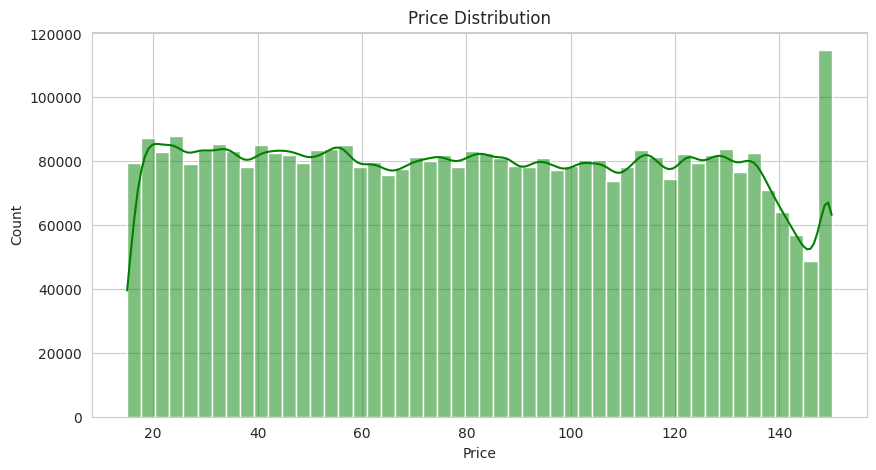

<Axes: xlabel='Weight Capacity (kg)', ylabel='Density'>

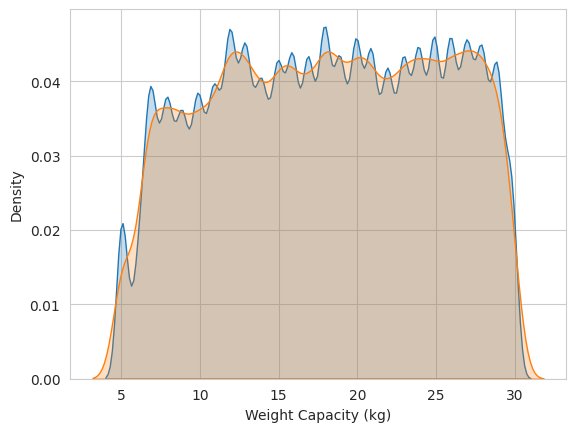

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Price"], bins=50, kde=True, color="green")
plt.title("Price Distribution")
plt.show()

sns.kdeplot(df["Weight Capacity (kg)"], label="Train", shade=True)
sns.kdeplot(test["Weight Capacity (kg)"], label="Test", shade=True)

In [9]:
cat_features = ["Size", "Brand", "Material", "Style", "Color", "Laptop Compartment", "Waterproof"]

df["Weight Capacity (kg)"] =  np.log1p(df["Weight Capacity (kg)"])
df["Compartments"] = np.log1p(df["Compartments"])

test["Weight Capacity (kg)"] = np.log1p(test["Weight Capacity (kg)"])
test["Compartments"] = np.log1p(test["Compartments"])

In [10]:
X = df.drop(columns=["Price"])
y = df["Price"]
display(X)

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg)
0,Jansport,Leather,Medium,1.124748,Yes,No,Tote,Black,1.262608
1,Jansport,Canvas,Small,1.223156,Yes,Yes,Messenger,Green,1.466723
2,Under Armour,Leather,Small,0.741276,Yes,No,Messenger,Red,1.353353
3,Nike,Nylon,Small,1.162283,Yes,No,Messenger,Green,1.290489
4,Adidas,Canvas,Medium,0.526589,Yes,Yes,Messenger,Green,1.368934
...,...,...,...,...,...,...,...,...,...
3994313,Nike,Canvas,NaN,0.869742,Yes,Yes,Messenger,Blue,1.474917
3994314,Puma,Leather,Small,1.223156,Yes,Yes,Tote,Blue,1.363854
3994315,Jansport,Canvas,Large,1.223156,No,No,Backpack,Red,1.359042
3994316,Puma,Canvas,NaN,0.741276,No,No,Backpack,Gray,1.480228


In [13]:
def feature_engineering_xgb(X_train, y_train, test, cat_features, top_corr_features=5, max_interactions=15):
    """
    Enhances dataset by:
    1. Handling missing values.
    2. Encoding categorical features using One-Hot Encoding (train & test).
    3. Identifying top correlated numerical features with Price (train only).
    4. Generating limited interaction features (train & test).
    5. Removing duplicate features.
    6. Selecting the best features using SelectKBest.
    
    Parameters:
    - X_train: Training Feature DataFrame
    - y_train: Training target variable (Price)
    - test: Test Feature DataFrame (no Price available)
    - cat_features: List of categorical feature names
    - top_corr_features: Number of top correlated numerical features to use in interactions
    - max_interactions: Maximum number of new features to generate from interactions
    
    Returns:
    - Transformed `X_train` and `Test` DataFrames with engineered features.
    - List of selected features from training data.
    """
    k_best=20
    
    # Copy data to prevent modification
    X_train = X_train.copy()
    test = test.copy()

    print("\n🛠️ Handling Missing Values...")
    
    # Fill categorical NaN with "Unknown" (Train & Test)
    X_train[cat_features] = X_train[cat_features].fillna("Unknown")
    test[cat_features] = test[cat_features].fillna("Unknown")

    # Fill numerical NaN with column median (Train & Test)
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    
    for col in num_cols:
        median_value = X_train[col].median()  # Use train median
        X_train[col] = X_train[col].fillna(median_value)
        test[col] = test[col].fillna(median_value)

    print("✅ Filled missing values in categorical and numerical features.")

    # Step 2: One-Hot Encoding (Fit on Train, Apply to Test)
    print("\n🔢 Applying One-Hot Encoding to Categorical Features...")
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)
    
    encoded_train = encoder.fit_transform(X_train[cat_features])
    encoded_test = encoder.transform(test[cat_features])  # Use trained encoder

    encoded_feature_names = encoder.get_feature_names_out(cat_features)

    df_train_encoded = pd.DataFrame(encoded_train, columns=encoded_feature_names, index=X_train.index)
    df_test_encoded = pd.DataFrame(encoded_test, columns=encoded_feature_names, index=test.index)

    # Drop original categorical columns
    X_train = X_train.drop(columns=cat_features)
    test = test.drop(columns=cat_features)

    # Merge One-Hot Encoded Features
    X_train = pd.concat([X_train, df_train_encoded], axis=1)
    test = pd.concat([test, df_test_encoded], axis=1)

    print(f"✅ One-Hot Encoded categorical features into {df_train_encoded.shape[1]} new features.")

    # Step 3: Compute Correlations (Train Only)
    corr_matrix = X_train.corrwith(y_train).abs().sort_values(ascending=False)
    print("\n🔍 Top 10 Features Most Correlated with Price:\n", corr_matrix.head(10))

    # Select top correlated numerical features for interactions (Train Only)
    top_features = corr_matrix.head(top_corr_features).index.tolist()
    numeric_cols = X_train[top_features].select_dtypes(include=[np.number]).columns.tolist()

    # Step 4: Generate LIMITED Interaction Features (Train & Test)
    print("\n⚙️ Generating Limited Interaction Features...")
    new_features = []
    interaction_count = 0  # Track number of generated features

    for col1, col2 in itertools.combinations(numeric_cols, 2):
        if interaction_count >= max_interactions:
            break  # Stop generating new features if max_interactions is reached

        X_train[f"{col1}_x_{col2}"] = X_train[col1] * X_train[col2]
        X_train[f"{col1}_div_{col2}"] = X_train[col1] / (X_train[col2] + 1e-6)  # Avoid division by zero
        test[f"{col1}_x_{col2}"] = test[col1] * test[col2]
        test[f"{col1}_div_{col2}"] = test[col1] / (test[col2] + 1e-6)

        new_features.extend([f"{col1}_x_{col2}", f"{col1}_div_{col2}"])
        interaction_count += 2

    print(f"✅ Created {interaction_count} new interaction features.")

    # Step 5: Remove Duplicate Features (Train & Test)
    print("\n🗑️ Removing Duplicate Features...")
    X_train = X_train.loc[:, ~X_train.columns.duplicated()]
    test = test.loc[:, ~test.columns.duplicated()]
    print(f"✅ Removed duplicate features. Remaining Train Features: {X_train.shape[1]}, Test Features: {test.shape[1]}")

    # Step 6: Feature Selection Using K-Fold Cross-Validation
    print("\n🔍 Selecting Best Features Using K-Fold Cross-Validation...")
    
   # Step 6: Feature Selection Using SelectKBest
    print("\n🔍 Selecting Best Features Using SelectKBest...")

    selector = SelectKBest(score_func=f_regression, k=k_best)
    X_train_selected = selector.fit_transform(X_train, y_train)
    test_selected = selector.transform(test)

    selected_features = X_train.columns[selector.get_support()].tolist()

    print(f"\n🎯 Selected Top {len(selected_features)} Features Based on SelectKBest:")
    print(selected_features)

    # Convert to DataFrame
    X_train_selected = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train.index)
    test_selected = pd.DataFrame(test_selected, columns=selected_features, index=test.index)

    return X_train_selected, test_selected, selected_features

In [14]:
def randomized_grid_search(X_train, y_train):
    xgb = XGBRegressor(objective="reg:squarederror", random_state=42)

    params = {
        "n_estimators": [100, 500, 1000],
        "learning_rate": [0.01, 0.05, 0.25, 0.1],
        "max_depth": [1, 3, 5, 7, 9],
        "min_child_weight": [1, 3, 5],
        "subsample": [0.4, 0.6, 0.8],
        "colsample_bytree": [0.5, 0.8, 0.9],
        "reg_lambda": [0, 1, 5, 10],
        "min_sample_loss": [0, 0.1, 0.5, 1, 3, 5, 10],
        "reg_alpha": [0, 0.1, 1]
    }

    grid_search = RandomizedSearchCV(xgb, params, cv=5, random_state=42, scoring="neg_mean_squared_error", verbose=1, n_jobs=1)
    grid_search.fit(X_train, y_train)
    print("Best parameters:", grid_search.best_params_)
    print("Best Score:", grid_search.best_score_ )

    return grid_search.best_params_, grid_search.best_score_

In [15]:
X_train_transformed, X_test_transformed, selected_features = feature_engineering_xgb(X, y, test, cat_features)

X_train, X_test, y_train, y_test = train_test_split(X_train_transformed, y, test_size=0.2, random_state=42, shuffle=True)
best_params = {"eval_metric": "rmse", "tree_method": "hist", "max_depth": 8, "min_child_weight": 1, "gamma": 0.0, "learning_rate": 0.2, 'subsample': 0.95, 'colsample_bytree': 1.0, 'alpha': 1, 'lambda': 1, 'seed': 0, 'random_state': 42}
xgb_boost = XGBRegressor(early_stopping_rounds=50, **best_params)

xgb_boost.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
print(f"Best XGBoost iteration using RMSE: {xgb_boost.best_iteration} \n")

y_pred = xgb_boost.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"XGBoost Root Mean Squared Error (RMSE): {rmse} \n")


🛠️ Handling Missing Values...
✅ Filled missing values in categorical and numerical features.

🔢 Applying One-Hot Encoding to Categorical Features...
✅ One-Hot Encoded categorical features into 32 new features.

🔍 Top 10 Features Most Correlated with Price:
 Weight Capacity (kg)    0.021184
Material_Leather        0.012757
Color_Black             0.011412
Brand_Adidas            0.010700
Size_Unknown            0.010544
Waterproof_Unknown      0.010349
Material_Polyester      0.010305
Color_Green             0.009772
Brand_Under Armour      0.009043
Color_Blue              0.007295
dtype: float64

⚙️ Generating Limited Interaction Features...
✅ Created 16 new interaction features.

🗑️ Removing Duplicate Features...
✅ Removed duplicate features. Remaining Train Features: 50, Test Features: 50

🔍 Selecting Best Features Using K-Fold Cross-Validation...

🔍 Selecting Best Features Using SelectKBest...

🎯 Selected Top 20 Features Based on SelectKBest:
['Weight Capacity (kg)', 'Size_Unknown'

In [16]:
test_pred = xgb_boost.predict(X_test_transformed, iteration_range=(0, xgb_boost.best_iteration))

submission = pd.read_csv("sample_submission.csv")
submission.to_csv("submission.csv", index=False)
display(submission)

,id,Price
0,300000,81.411
1,300001,81.411
2,300002,81.411
3,300003,81.411
4,300004,81.411
...,...,...
199995,499995,81.411
199996,499996,81.411
199997,499997,81.411
199998,499998,81.411
